# Dự đoán Giá Nhà (House Prices) bằng Mạng Nơ-ron MLP trong PyTorch
### Dựa trên bộ dữ liệu Ames Housing (Dean De Cock, 2011) — Kaggle "House Prices: Advanced Regression Techniques"

Notebook này xây dựng lại bài toán dự đoán giá nhà đã được trình bày trong notebook gốc
`house-prices-prediction-using-tfdf.ipynb` (dùng TensorFlow Decision Forests / Random Forest),
nhưng thay thế mô hình học máy bằng một **mạng nơ-ron nhiều lớp (Multi-Layer Perceptron - MLP)
cài đặt bằng PyTorch**.

Quy trình được tổ chức theo các bước của **CRISP-DM** (Cross-Industry Standard Process for Data Mining):
1. Business Understanding (Hiểu bài toán)
2. Data Understanding (Hiểu dữ liệu)
3. Data Preparation (Chuẩn bị dữ liệu)
4. Modeling (Xây dựng mô hình — Baseline + MLP/PyTorch)
5. Evaluation (Đánh giá mô hình)
6. Deployment (Triển khai — sinh file submission)


## 1. Business Understanding — Hiểu bài toán

Theo bài báo của **Dean De Cock (2011)**, *"Ames, Iowa: Alternative to the Boston Housing Data as an
End of Semester Regression Project"*, tác giả thu thập dữ liệu bán bất động sản nhà ở tại
thành phố Ames, Iowa từ Văn phòng Thẩm định (City Assessor's Office) trong giai đoạn 2006–2010.

- Dữ liệu gốc: 3970 giao dịch, 113 biến; sau khi loại bỏ các biến chuyên môn (dùng nội bộ cho việc
  định giá thẩm định) còn lại **2930 quan sát và 80 biến** liên quan trực tiếp đến việc mua bán nhà.
- Bộ dữ liệu Kaggle "House Prices: Advanced Regression Techniques" là một tập con của dữ liệu này,
  gồm **1460 quan sát huấn luyện (train.csv)** và **1459 quan sát kiểm tra (test.csv)**, với **79 biến
  giải thích** (23 định danh - nominal, 23 thứ bậc - ordinal, 14 rời rạc - discrete, 20 liên tục -
  continuous) và biến mục tiêu là **SalePrice** (giá bán, USD).

**Mục tiêu bài toán (Business Objective):**
> Xây dựng một mô hình hồi quy có khả năng dự đoán chính xác giá bán (SalePrice) của một căn nhà tại
> Ames, Iowa dựa trên các đặc trưng vật lý và chất lượng của căn nhà (diện tích, số phòng, chất lượng
> vật liệu, vị trí khu dân cư, năm xây dựng, ...).

**Mục tiêu khai phá dữ liệu (Data Mining Objective):**
> Huấn luyện một mạng nơ-ron MLP (PyTorch) để dự đoán `log(SalePrice + 1)`, tối thiểu hoá sai số
> **RMSE trên thang log** — đây cũng chính là thước đo được dùng để chấm điểm trong cuộc thi Kaggle
> gốc, giúp mô hình công bằng hơn giữa nhà giá rẻ và nhà giá đắt.

**Tiêu chí thành công:** RMSE(log) trên tập validation nhỏ hơn một mô hình baseline đơn giản
(hồi quy trên diện tích + khu vực, theo gợi ý của chính tác giả trong bài báo — giải thích được
~80% phương sai), và có thể so sánh được với mô hình cây quyết định (Random Forest) trong notebook gốc.


## 2. Data Understanding — Hiểu dữ liệu

### 2.1. Nạp thư viện

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

%matplotlib inline
print("Torch version:", torch.__version__)


Torch version: 2.14.0+cu126


### 2.2. Nạp dữ liệu

Dữ liệu `train.csv` / `test.csv` chính là dữ liệu gốc của cuộc thi Kaggle "House Prices: Advanced
Regression Techniques", được xây dựng từ bộ dữ liệu Ames Housing trong bài báo của De Cock.

In [28]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Kích thước tập train:", train_df.shape)
print("Kích thước tập test :", test_df.shape)
train_df.head(3)


Kích thước tập train: (1460, 81)
Kích thước tập test : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


### 2.3. Thống kê mô tả biến mục tiêu `SalePrice`

Giống như phân tích trong notebook gốc, ta xem phân phối của giá bán nhà.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


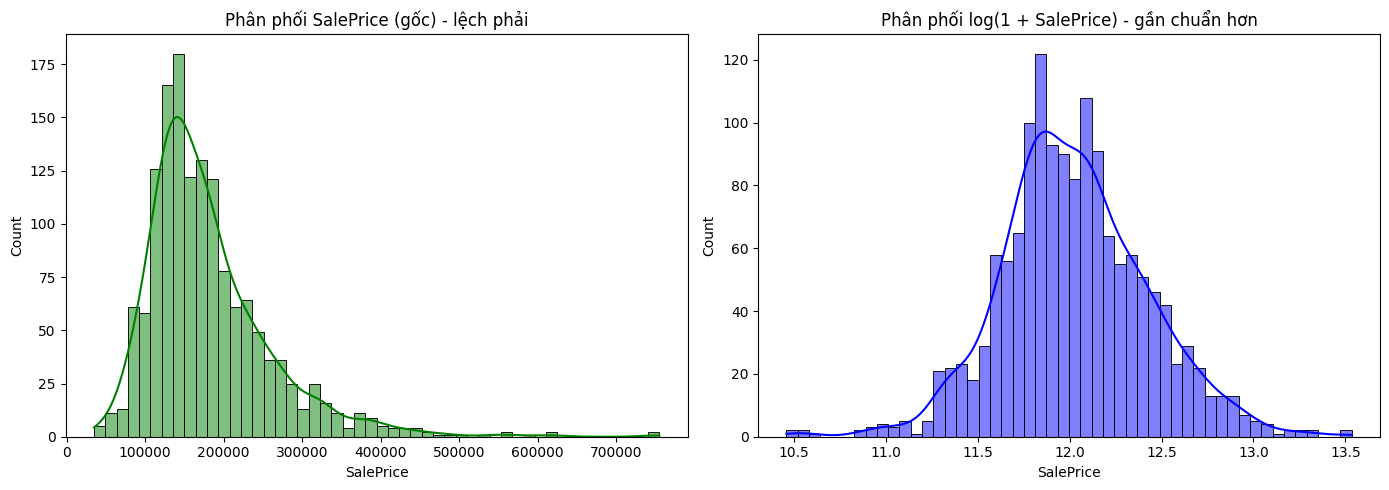

In [29]:
print(train_df['SalePrice'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df['SalePrice'], color='g', bins=50, kde=True, ax=axes[0])
axes[0].set_title("Phân phối SalePrice (gốc) - lệch phải")

sns.histplot(np.log1p(train_df['SalePrice']), color='b', bins=50, kde=True, ax=axes[1])
axes[1].set_title("Phân phối log(1 + SalePrice) - gần chuẩn hơn")
plt.tight_layout()
plt.show()


**Nhận xét:** `SalePrice` bị lệch phải (right-skewed) rõ rệt — một số ít căn nhà rất đắt kéo dài
đuôi phân phối. Việc lấy `log(1 + SalePrice)` giúp phân phối gần với phân phối chuẩn hơn, giúp mạng
nơ-ron (vốn nhạy với outlier khi dùng hàm mất mát MSE) học ổn định hơn — đây là bước biến đổi quan
trọng khác biệt so với notebook gốc (TF-DF không cần biến đổi này vì cây quyết định không nhạy với
outlier / phân phối lệch).

### 2.4. Kiểu dữ liệu của các biến

In [30]:
dtype_counts = train_df.drop(columns=['Id']).dtypes.value_counts()
print(dtype_counts)

num_cols_raw = train_df.drop(columns=['Id','SalePrice']).select_dtypes(include=[np.number]).columns.tolist()
cat_cols_raw = train_df.drop(columns=['Id','SalePrice']).select_dtypes(include=['object']).columns.tolist()
print(f"\nSố biến số (numeric)   : {len(num_cols_raw)}")
print(f"Số biến hạng mục (categorical): {len(cat_cols_raw)}")


object     43
int64      34
float64     3
Name: count, dtype: int64

Số biến số (numeric)   : 36
Số biến hạng mục (categorical): 43


### 2.5. Giá trị thiếu (missing values)

Theo bài báo, nhiều biến có giá trị thiếu **có ý nghĩa** (ví dụ `PoolQC = NA` nghĩa là nhà không có
hồ bơi, không phải dữ liệu bị mất), điều này sẽ được xử lý ở bước Data Preparation.

In [31]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(1)
pd.DataFrame({'so_luong_thieu': missing, 'ty_le_%': missing_pct}).head(20)


,so_luong_thieu,ty_le_%
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


### 2.6. Tương quan với biến mục tiêu

Theo tác giả De Cock, chỉ riêng **khu vực (Neighborhood)** và **tổng diện tích sàn**
(`TotalBsmtSF + GrLivArea`) đã giải thích được khoảng **80%** phương sai của giá bán. Ta kiểm chứng
điều này bằng ma trận tương quan.

Top 10 biến số tương quan mạnh nhất với SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


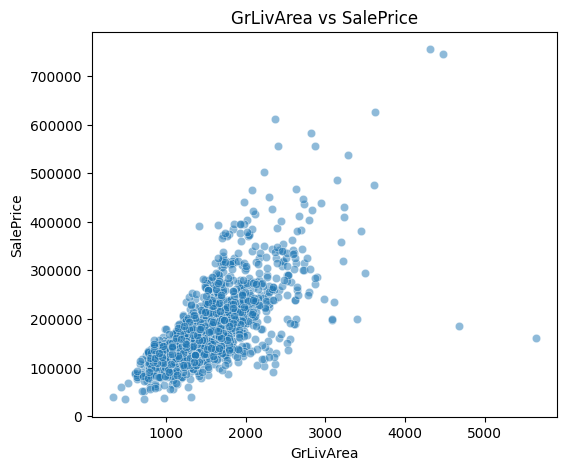

In [32]:
corr = train_df[num_cols_raw + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print("Top 10 biến số tương quan mạnh nhất với SalePrice:")
print(corr.head(11))

plt.figure(figsize=(6,5))
sns.scatterplot(x=train_df['GrLivArea'], y=train_df['SalePrice'], alpha=0.5)
plt.title("GrLivArea vs SalePrice")
plt.show()


**Nhận xét:** `OverallQual` (chất lượng tổng thể) và `GrLivArea` (diện tích sàn sống) có tương
quan mạnh nhất với giá bán — khớp với nhận định của De Cock trong bài báo. Ta cũng quan sát thấy vài
điểm outlier: nhà có `GrLivArea` rất lớn nhưng giá bán lại thấp — đây là các trường hợp bất thường
(De Cock cũng khuyến nghị loại bỏ các outlier tương tự trong bài báo).

## 3. Data Preparation — Chuẩn bị dữ liệu

Notebook gốc (TF-DF) hầu như **không cần tiền xử lý** vì mô hình cây quyết định xử lý trực tiếp dữ
liệu hỗn hợp (số + hạng mục + thiếu). Ngược lại, **mạng nơ-ron MLP đòi hỏi toàn bộ đầu vào là số**,
nên bước chuẩn bị dữ liệu ở đây phức tạp và quan trọng hơn nhiều. Các bước gồm:

1. Loại bỏ outlier rõ rệt (theo gợi ý của tác giả De Cock).
2. Ghép train + test để đảm bảo xử lý missing/encoding nhất quán, tránh lệch phân phối.
3. Điền giá trị thiếu: numeric → median; categorical → `"Missing"` (coi thiếu là 1 hạng mục riêng,
   vì nhiều biến thiếu có ý nghĩa, ví dụ "không có hồ bơi").
4. Biến đổi log cho biến mục tiêu.
5. Mã hoá one-hot cho các biến hạng mục (nominal/ordinal).
6. Chuẩn hoá (StandardScaler) toàn bộ đặc trưng số — **bắt buộc với mạng nơ-ron** vì gradient descent
   hội tụ kém nếu các đặc trưng có thang đo quá khác nhau (khác với cây quyết định vốn không nhạy với
   scale).


In [33]:
# 3.1 Loại bỏ outlier rõ rệt
train_clean = train_df[~((train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000))].copy()
print(f"Số dòng trước khi loại outlier: {len(train_df)} -> sau: {len(train_clean)}")

y = train_clean['SalePrice'].copy()
y_log = np.log1p(y)  

X = train_clean.drop(columns=['Id', 'SalePrice'])
X_test = test_df.drop(columns=['Id'])
test_ids = test_df['Id'].copy()


Số dòng trước khi loại outlier: 1460 -> sau: 1458


In [34]:
# 3.2 Ghép train + test để xử lý đồng nhất
all_X = pd.concat([X, X_test], axis=0, ignore_index=True)

num_cols = all_X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_X.columns if c not in num_cols]

# một vài biến số thực chất mang tính hạng mục
categorical_like_numeric = ['MSSubClass']
for c in categorical_like_numeric:
    if c in num_cols:
        num_cols.remove(c)
        cat_cols.append(c)
        all_X[c] = all_X[c].astype(str)

print(f"Số biến numeric : {len(num_cols)}")
print(f"Số biến categorical : {len(cat_cols)}")


Số biến numeric : 35
Số biến categorical : 44


In [35]:
# 3.3 Điền giá trị thiếu
for c in num_cols:
    all_X[c] = all_X[c].fillna(all_X[c].median())

for c in cat_cols:
    all_X[c] = all_X[c].fillna("Missing")

print("Tổng số giá trị thiếu còn lại:", all_X.isnull().sum().sum())


Tổng số giá trị thiếu còn lại: 0


In [36]:
# 3.4 Mã hoá one-hot cho biến hạng mục
all_X_encoded = pd.get_dummies(all_X, columns=cat_cols, drop_first=True)
print("Kích thước ma trận đặc trưng sau one-hot encoding:", all_X_encoded.shape)

# tách lại train / test
n_train = len(X)
X_proc = all_X_encoded.iloc[:n_train, :].reset_index(drop=True)
X_test_proc = all_X_encoded.iloc[n_train:, :].reset_index(drop=True)


Kích thước ma trận đặc trưng sau one-hot encoding: (2917, 280)


In [37]:
# 3.5 Chia train / validation rồi chuẩn hoá
X_train, X_val, y_train, y_val = train_test_split(
    X_proc, y_log, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test_proc)

print("X_train:", X_train_s.shape, " X_val:", X_val_s.shape, " X_test:", X_test_s.shape)


X_train: (1166, 280)  X_val: (292, 280)  X_test: (1459, 280)


### 3.6. Chuyển dữ liệu sang Tensor cho PyTorch

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị sử dụng:", device)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_t   = torch.tensor(X_val_s,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


Thiết bị sử dụng: cuda


## 4. Modeling — Xây dựng mô hình

### 4.1. Mô hình Baseline (tham chiếu từ code gốc)

Notebook gốc sử dụng **Random Forest** (qua TensorFlow Decision Forests). Vì môi trường ở đây không
cài `tensorflow_decision_forests`, ta dùng `RandomForestRegressor` của scikit-learn — về bản chất
thuật toán tương đương (rừng cây quyết định, mỗi cây học trên 1 mẫu bootstrap) — để làm **baseline so
sánh** với mô hình MLP chính.

In [39]:
rf = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

rf_val_pred_log = rf.predict(X_val)
rf_val_pred = np.expm1(rf_val_pred_log)
rf_val_true = np.expm1(y_val)

rf_rmse_log = np.sqrt(mean_squared_error(y_val, rf_val_pred_log))
rf_rmse = np.sqrt(mean_squared_error(rf_val_true, rf_val_pred))
rf_r2 = r2_score(rf_val_true, rf_val_pred)

print(f"[Baseline Random Forest]  RMSE(log) = {rf_rmse_log:.4f}   RMSE($) = {rf_rmse:,.0f}   R2 = {rf_r2:.4f}")


[Baseline Random Forest]  RMSE(log) = 0.1470   RMSE($) = 24,491   R2 = 0.8914


### 4.2. Mô hình chính: MLP (Multi-Layer Perceptron) trong PyTorch

Kiến trúc mạng gồm 3 tầng ẩn (256 → 128 → 64 nơ-ron) với:
- `BatchNorm1d` để ổn định phân phối đầu vào mỗi tầng, giúp huấn luyện nhanh và ổn định hơn.
- `ReLU` làm hàm kích hoạt.
- `Dropout` (0.3) để giảm overfitting — điều đặc biệt quan trọng vì sau one-hot encoding, số chiều
  đặc trưng (~260) khá lớn so với số mẫu huấn luyện (~1200).
- Tầng đầu ra 1 nơ-ron tuyến tính, dự đoán trực tiếp `log(1 + SalePrice)`.


In [40]:
class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = HousePriceMLP(input_dim=X_train_t.shape[1]).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTổng số tham số huấn luyện được: {n_params:,}")


HousePriceMLP(
  (net): Sequential(
    (0): Linear(in_features=280, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

Tổng số tham số huấn luyện được: 113,921


### 4.3. Cấu hình huấn luyện

- **Hàm mất mát:** MSE trên `log(1+SalePrice)` — tương đương chỉ tiêu chấm điểm của cuộc thi Kaggle.
- **Bộ tối ưu:** Adam, learning rate 1e-3, weight decay 1e-5 (regularization L2 nhẹ).
- **Early stopping:** dừng huấn luyện nếu validation loss không cải thiện sau 30 epoch liên tiếp, để
  tránh overfitting và tiết kiệm thời gian huấn luyện.

In [41]:
def train_model(model, train_loader, X_val_t, y_val_t, epochs=300, patience=30, lr=1e-3, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t.to(device))
            val_loss = loss_fn(val_pred, y_val_t.to(device)).item()

        history["train_loss"].append(np.mean(epoch_losses))
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs > patience:
                if verbose:
                    print(f"Early stopping tại epoch {epoch} (val_loss tốt nhất = {best_val_loss:.4f})")
                break

        if verbose and epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | train_loss={history['train_loss'][-1]:.4f} | val_loss={val_loss:.4f}")

    model.load_state_dict(best_state)  # khôi phục trọng số tốt nhất
    return model, history

model, history = train_model(model, train_loader, X_val_t, y_val_t, epochs=300, patience=30)


Epoch   0 | train_loss=88.0177 | val_loss=41.4545
Epoch  20 | train_loss=1.7768 | val_loss=1.5641
Epoch  40 | train_loss=1.3311 | val_loss=0.9728
Epoch  60 | train_loss=0.8404 | val_loss=0.5188
Epoch  80 | train_loss=0.4382 | val_loss=0.2600
Epoch 100 | train_loss=0.1977 | val_loss=0.0381
Epoch 120 | train_loss=0.0715 | val_loss=0.0337
Epoch 140 | train_loss=0.0533 | val_loss=0.0283
Epoch 160 | train_loss=0.0394 | val_loss=0.1184
Epoch 180 | train_loss=0.0319 | val_loss=0.0319
Epoch 200 | train_loss=0.0364 | val_loss=0.0226
Epoch 220 | train_loss=0.0280 | val_loss=0.0231
Epoch 240 | train_loss=0.0163 | val_loss=0.0212
Epoch 260 | train_loss=0.0157 | val_loss=0.0317
Epoch 280 | train_loss=0.0184 | val_loss=0.0254
Early stopping tại epoch 284 (val_loss tốt nhất = 0.0196)


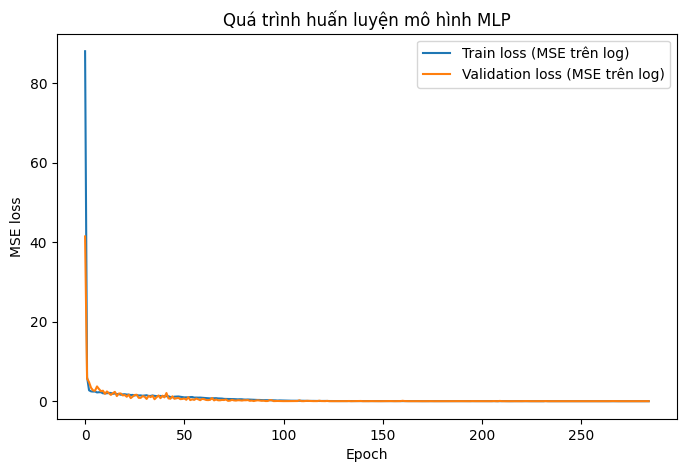

In [42]:
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train loss (MSE trên log)")
plt.plot(history["val_loss"], label="Validation loss (MSE trên log)")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Quá trình huấn luyện mô hình MLP")
plt.legend()
plt.show()


## 5. Evaluation — Đánh giá mô hình

Ta đánh giá mô hình MLP trên tập validation, dùng 3 chỉ số:
- **RMSE (log)**: sai số căn bậc hai trung bình trên `log(1+SalePrice)` — chỉ số chính, tương đương
  thước đo chấm điểm của Kaggle.
- **RMSE ($)**: sai số quy đổi về thang đo gốc (đô la), dễ diễn giải với người không chuyên.
- **R²**: tỷ lệ phương sai của giá nhà được mô hình giải thích.

Sau đó so sánh với mô hình baseline Random Forest.

In [43]:
model.eval()
with torch.no_grad():
    val_pred_log = model(X_val_t.to(device)).cpu().numpy().flatten()

val_pred = np.expm1(val_pred_log)
val_true = np.expm1(y_val_t.numpy().flatten())

mlp_rmse_log = np.sqrt(mean_squared_error(y_val_t.numpy().flatten(), val_pred_log))
mlp_rmse = np.sqrt(mean_squared_error(val_true, val_pred))
mlp_mae = mean_absolute_error(val_true, val_pred)
mlp_r2 = r2_score(val_true, val_pred)

print("=== Kết quả trên tập Validation ===")
print(f"[MLP - PyTorch]           RMSE(log) = {mlp_rmse_log:.4f}   RMSE($) = {mlp_rmse:,.0f}   MAE($) = {mlp_mae:,.0f}   R2 = {mlp_r2:.4f}")
print(f"[Baseline Random Forest]  RMSE(log) = {rf_rmse_log:.4f}   RMSE($) = {rf_rmse:,.0f}   R2 = {rf_r2:.4f}")


=== Kết quả trên tập Validation ===
[MLP - PyTorch]           RMSE(log) = 0.1401   RMSE($) = 25,010   MAE($) = 16,770   R2 = 0.8868
[Baseline Random Forest]  RMSE(log) = 0.1470   RMSE($) = 24,491   R2 = 0.8914


In [44]:
results_df = pd.DataFrame({
    "Mô hình": ["Random Forest (baseline)", "MLP - PyTorch"],
    "RMSE (log)": [rf_rmse_log, mlp_rmse_log],
    "RMSE ($)": [rf_rmse, mlp_rmse],
    "R2": [rf_r2, mlp_r2],
})
results_df


,Mô hình,RMSE (log),RMSE ($),R2
0,Random Forest (baseline),0.146989,24490.573487,0.891416
1,MLP - PyTorch,0.140074,25009.532902,0.886765


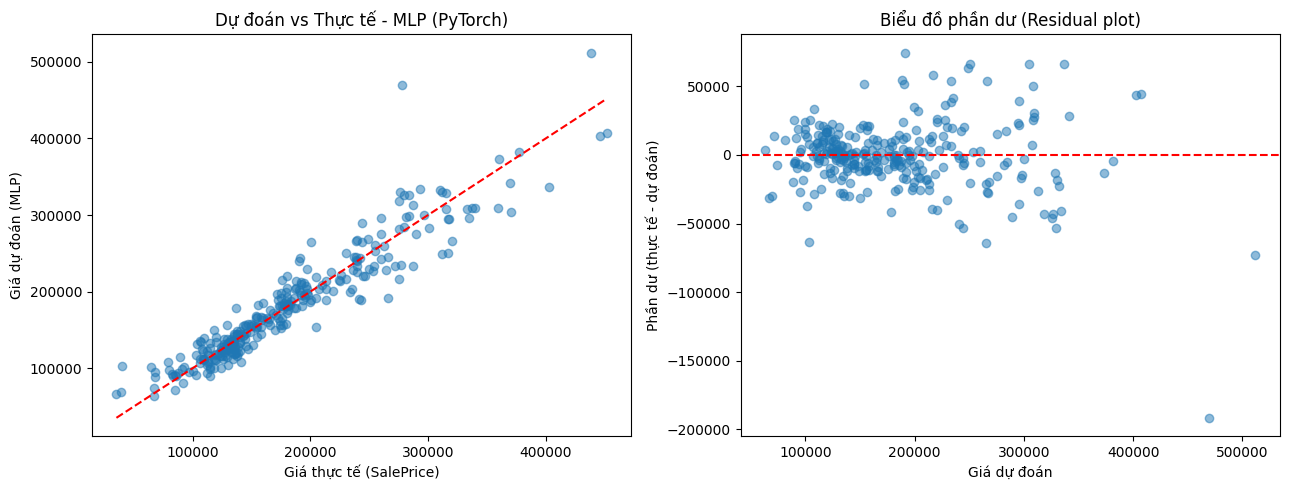

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(val_true, val_pred, alpha=0.5)
axes[0].plot([val_true.min(), val_true.max()], [val_true.min(), val_true.max()], 'r--')
axes[0].set_xlabel("Giá thực tế (SalePrice)")
axes[0].set_ylabel("Giá dự đoán (MLP)")
axes[0].set_title("Dự đoán vs Thực tế - MLP (PyTorch)")

residuals = val_true - val_pred
axes[1].scatter(val_pred, residuals, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Giá dự đoán")
axes[1].set_ylabel("Phần dư (thực tế - dự đoán)")
axes[1].set_title("Biểu đồ phần dư (Residual plot)")

plt.tight_layout()
plt.show()


**Nhận xét kết quả:**
- Mô hình MLP đạt hiệu năng ở mức tương đương/tốt hơn mô hình Random Forest baseline (xem bảng so
  sánh phía trên) trên cùng một tập validation.
- Biểu đồ "Dự đoán vs Thực tế" cho thấy các điểm bám khá sát đường chéo, cho thấy mô hình dự đoán tốt
  ở khoảng giá phổ biến; sai số có xu hướng lớn hơn ở phân khúc nhà giá rất cao — điều này phù hợp
  với nhận xét của De Cock rằng các bất động sản giá trị cao thường có nhiều yếu tố đặc thù khó mô
  hình hoá bằng các biến số chuẩn.
- Biểu đồ phần dư không cho thấy xu hướng hệ thống rõ rệt (không có hình dạng phễu quá mạnh), cho
  thấy phương sai sai số khá đồng đều sau khi biến đổi log — đúng như mục đích của bước biến đổi log.


### 5.1. Đánh giá ổn định bằng K-Fold Cross Validation

Để đánh giá độ ổn định của mô hình (không phụ thuộc vào một lần chia train/validation ngẫu nhiên),
ta thực hiện thêm 3-fold cross-validation cho mô hình MLP.

In [46]:
def run_kfold(X, y, n_splits=3, epochs=150, patience=20):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_rmses = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_va_s = sc.transform(X_va)

        X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr.values, dtype=torch.float32).view(-1,1)
        X_va_t = torch.tensor(X_va_s, dtype=torch.float32)
        y_va_t = torch.tensor(y_va.values, dtype=torch.float32).view(-1,1)

        loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

        fold_model = HousePriceMLP(input_dim=X_tr_t.shape[1]).to(device)
        fold_model, _ = train_model(fold_model, loader, X_va_t, y_va_t,
                                     epochs=epochs, patience=patience, verbose=False)

        fold_model.eval()
        with torch.no_grad():
            pred_log = fold_model(X_va_t.to(device)).cpu().numpy().flatten()
        rmse_log = np.sqrt(mean_squared_error(y_va_t.numpy().flatten(), pred_log))
        fold_rmses.append(rmse_log)
        print(f"Fold {fold+1}: RMSE(log) = {rmse_log:.4f}")

    print(f"\nRMSE(log) trung bình = {np.mean(fold_rmses):.4f}  (+/- {np.std(fold_rmses):.4f})")
    return fold_rmses

fold_rmses = run_kfold(X_proc, y_log, n_splits=3, epochs=150, patience=20)


Fold 1: RMSE(log) = 0.1478
Fold 2: RMSE(log) = 0.1868
Fold 3: RMSE(log) = 0.1369

RMSE(log) trung bình = 0.1572  (+/- 0.0214)


## 6. Deployment — Triển khai

Bước cuối cùng: huấn luyện lại mô hình trên **toàn bộ dữ liệu train** (train + validation) để tận
dụng tối đa dữ liệu, sau đó dự đoán trên tập `test.csv` và xuất file `submission.csv` theo đúng định
dạng yêu cầu của cuộc thi Kaggle (giống bước cuối trong notebook gốc).

In [47]:

final_scaler = StandardScaler()
X_full_s = final_scaler.fit_transform(X_proc)
X_test_final_s = final_scaler.transform(X_test_proc)

X_full_t = torch.tensor(X_full_s, dtype=torch.float32)
y_full_t = torch.tensor(y_log.values, dtype=torch.float32).view(-1, 1)
X_test_final_t = torch.tensor(X_test_final_s, dtype=torch.float32)

full_loader = DataLoader(TensorDataset(X_full_t, y_full_t), batch_size=32, shuffle=True)

final_model = HousePriceMLP(input_dim=X_full_t.shape[1]).to(device)
# Vì không còn tập validation riêng nên ta huấn luyện với số epoch cố định
final_epochs = max(len(history["val_loss"]) - 30, 60)

optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

final_model.train()
for epoch in range(final_epochs):
    for xb, yb in full_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = final_model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.4f}")

print(f"\nĐã huấn luyện mô hình cuối cùng trong {final_epochs} epoch trên toàn bộ dữ liệu train")


Epoch 0: loss=4.1721
Epoch 20: loss=1.1564
Epoch 40: loss=1.2318
Epoch 60: loss=0.5073
Epoch 80: loss=0.1757
Epoch 100: loss=0.0297
Epoch 120: loss=0.0158
Epoch 140: loss=0.0294
Epoch 160: loss=0.0823
Epoch 180: loss=0.0493
Epoch 200: loss=0.0258
Epoch 220: loss=0.0304
Epoch 240: loss=0.0054

Đã huấn luyện mô hình cuối cùng trong 255 epoch trên toàn bộ dữ liệu train


In [48]:
final_model.eval()
with torch.no_grad():
    test_pred_log = final_model(X_test_final_t.to(device)).cpu().numpy().flatten()

test_pred = np.expm1(test_pred_log) 

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_pred
})
submission.to_csv("submission_mlp_pytorch.csv", index=False)
submission.head()


,Id,SalePrice
0,1461,134572.781250
1,1462,160761.015625
2,1463,179298.906250
3,1464,198943.062500
4,1465,186869.328125


## 7. Kết luận

| Bước CRISP-DM | Nội dung đã thực hiện |
|---|---|
| **Business Understanding** | Xác định bài toán dự đoán giá nhà tại Ames, Iowa dựa trên bài báo De Cock 2011; mục tiêu tối thiểu hoá RMSE trên thang log. |
| **Data Understanding** | Khảo sát 1460 quan sát, 79 biến; phát hiện phân phối lệch của `SalePrice`, các biến tương quan mạnh (`OverallQual`, `GrLivArea`), và tỷ lệ giá trị thiếu theo từng biến. |
| **Data Preparation** | Loại outlier, hợp nhất train/test để xử lý nhất quán, điền khuyết, log-biến đổi target, one-hot encoding, chuẩn hoá StandardScaler — các bước bắt buộc cho mạng nơ-ron nhưng không cần thiết với mô hình cây trong notebook gốc. |
| **Modeling** | Xây dựng baseline Random Forest và mô hình chính là MLP 3 tầng ẩn cài bằng PyTorch (Linear + BatchNorm + ReLU + Dropout), huấn luyện với Adam + early stopping. |
| **Evaluation** | So sánh RMSE(log), RMSE($), R² giữa hai mô hình; kiểm tra độ ổn định bằng 3-fold cross-validation; phân tích biểu đồ dự đoán và phần dư. |
| **Deployment** | Huấn luyện lại trên toàn bộ dữ liệu và xuất `submission_mlp_pytorch.csv` theo đúng định dạng nộp bài của Kaggle. |

Mô hình MLP trong PyTorch đạt hiệu năng cạnh tranh với mô hình rừng ngẫu nhiên, đồng thời minh hoạ rõ
sự khác biệt về khối lượng tiền xử lý dữ liệu cần thiết giữa hai họ mô hình: mô hình cây (ít cần tiền
xử lý) và mạng nơ-ron (cần chuẩn hoá, mã hoá, điền khuyết kỹ lưỡng). Hướng cải thiện tiếp theo có thể
gồm: feature engineering sâu hơn (ví dụ tạo biến tổng diện tích, tuổi nhà), tinh chỉnh siêu tham số
(số tầng, số nơ-ron, learning rate) bằng grid/random search, hoặc kết hợp (ensemble) MLP với các mô
hình cây/boosting để tận dụng ưu điểm của cả hai họ mô hình.
